In [1]:
import pandas as pd
import re

In [2]:
data_main = pd.read_csv('data_main.csv')

In [3]:
data_main.tail()

,Timestamp,What is your birth year? (e.g. 1998),Gender?,What is your highest level of education?,What industry do you work in?,How would you rate your technical knowledge of AI?,How often do you use AI-powered tools?,What AI-powered services do you use most frequently? \n(You can choose multiple),Why do you typically use AI?,"Have you noticed AI-generated content (e.g., news, ads, recommendations) influencing your choices in any of the following?",...,"Do you think we should trust AI to make critical decisions in Customer Service (e.g., AI chatbots solving queries)?",How much do you trust AI to make critical decisions in Customer Service?,Have you ever experienced an AI-driven decision that felt unfair or biased?,Do you believe AI will replace jobs in your industry within the next 10 years?,Do you believe AI will create more jobs than it eliminates?,Are you actively learning new skills to adapt to AI-driven changes in the job market?,What is your biggest concern about AI?,Do you think AI should be more strictly regulated by governments?,Do you believe AI should be required to disclose when its content is AI-generated?,"How do you feel about AI making creative works (e.g., writing books, making music, generating art)?"
215,2025/05/25 12:20:50 pm EEST,2006,Male,HSC,Student,Intermediate,Weekly- A few times,ChatGPT;Google Assistant,Coding;Personal-Use;Education,Social media content consumption;Education/lea...,...,Yes,4,No,No,No,Yes,Privacy and data security risks;AI replacing h...,"Sometimes, but not too restrictive","Only in certain cases (e.g., news, official do...",AI-generated content is exciting and beneficial
216,2025/05/25 12:20:52 pm EEST,2005,Male,Bachelor,Student,Expert,Weekly- A few times,ChatGPT,Data-Analysis,Social media content consumption,...,No,4,Yes,Yes-but-not-completely,Maybe,Yes,Privacy and data security risks,"Sometimes, but not too restrictive","Only in certain cases (e.g., news, official do...",It depends on how AI is used
217,2025/05/25 12:21:05 pm EEST,2003,Male,HSC,Student,Intermediate,Daily,ChatGPT;Deep Seek,Data-Analysis;Personal-Use;Education,Career decisions;Education/learning habits,...,Maybe,3,Maybe,Unsure,Maybe,Yes,Privacy and data security risks,"Yes, AI should have strong legal restrictions","Only in certain cases (e.g., news, official do...",AI-generated content is concerning and threate...
218,2025/05/25 4:29:16 pm EEST,2005,Male,Bachelor,Student,Beginner,Weekly- A few times,ChatGPT;Google Assistant,Personal-Use;Assignment;Education,Online shopping;Social media content consumpti...,...,Maybe,3,Maybe,Yes,Maybe,No-Effect-in-my-career,AI being used for misinformation and deepfakes...,"Sometimes, but not too restrictive","Yes, AI-generated content should always be lab...",AI-generated content is exciting and beneficial
219,2025/08/03 2:04:08 am EEST,1999,Male,HSC,Student,Expert,Daily,ChatGPT;Gemini;Deep Seek;Google Assistant,Coding;Personal-Use;Assignment;Education,Online shopping;Social media content consumption,...,Yes,5,Yes,No,Yes,Yes,Job loss and automation replacing workers;Priv...,"Yes, AI should have strong legal restrictions","Yes, AI-generated content should always be lab...",It depends on how AI is used


In [4]:
data_main.columns

Index(['Timestamp', 'What is your birth year? (e.g. 1998)', 'Gender?',
       '  What is your highest level of education?  ',
       '  What industry do you work in?  ',
       '  How would you rate your technical knowledge of AI?  ',
       '  How often do you use AI-powered tools?  ',
       'What AI-powered services do you use most frequently? \n(You can choose multiple) ',
       '  Why do you typically use AI?  ',
       'Have you noticed AI-generated content (e.g., news, ads, recommendations) influencing your choices in any of the following?   ',
       'Do you think that AI recommendation based on your own choice is helping you?',
       'Do you think that we should be more concern about using AI system?',
       'Do you think we should trust AI to make critical decisions in  Healthcare (e.g., AI diagnosing diseases)?',
       'How much do you trust AI to make critical decisions in Healthcare?',
       'Do you think we should trust AI to make critical decisions in  Finance (e.g.

In [5]:
data_main.columns = data_main.columns.str.strip().str.replace("\n", " ", regex=True)

In [6]:
data = data_main.iloc[:, 1:12]

In [7]:
data.head()

,What is your birth year? (e.g. 1998),Gender?,What is your highest level of education?,What industry do you work in?,How would you rate your technical knowledge of AI?,How often do you use AI-powered tools?,What AI-powered services do you use most frequently? (You can choose multiple),Why do you typically use AI?,"Have you noticed AI-generated content (e.g., news, ads, recommendations) influencing your choices in any of the following?",Do you think that AI recommendation based on your own choice is helping you?,Do you think that we should be more concern about using AI system?
0,1997,Male,Bachelor,Education,Expert,Daily,ChatGPT;Gemini,Data-Analysis;Coding;Personal-Use;Assignment;E...,Online shopping;Social media content consumption,Maybe,Yes
1,1995,Male,Bachelor,Student,Expert,Daily,ChatGPT;Gemini;Google Assistant;Grammarly,Data-Analysis;Coding;Personal-Use;Assignment;E...,Online shopping;Social media content consumpti...,Yes,Yes
2,2001,Female,HSC,Student,Intermediate,Weekly- A few times,Gemini;Google Assistant,Personal-Use;Education,Online shopping;Social media content consumption,Yes,Maybe
3,1973,Female,HSC,Others,NaN,Monthly- A few times,Google Assistant,Personal-Use,None of the above,No,Yes
4,1996,Female,Bachelor,Technology-IT,Intermediate,Daily,ChatGPT;Gemini;Siri;Grammarly,Data-Analysis;Coding;Personal-Use;Assignment;E...,Online shopping;Education/learning habits,Yes,Yes


In [8]:
new_names = {
    "What is your birth year? (e.g. 1998)": "BirthYear",
    "Gender?": "Gender",
    "What is your highest level of education?": "Education",
    "What industry do you work in?": "Industry",
    "How would you rate your technical knowledge of AI?": "AI_Knowledge",
    "How often do you use AI-powered tools?": "AI_Usage",
    "What AI-powered services do you use most frequently?  (You can choose multiple)": "AI_Services",
    "Why do you typically use AI?": "AI_Purpose",
    "Have you noticed AI-generated content (e.g., news, ads, recommendations) influencing your choices in any of the following?": "AI_Influence",
    "Do you think that AI recommendation based on your own choice is helping you?": "AI_Helpfulness",
    "Do you think that we should be more concern about using AI system?": "AI_Concern"
}

data = data.rename(columns=new_names)


In [9]:
data.head()

,BirthYear,Gender,Education,Industry,AI_Knowledge,AI_Usage,AI_Services,AI_Purpose,AI_Influence,AI_Helpfulness,AI_Concern
0,1997,Male,Bachelor,Education,Expert,Daily,ChatGPT;Gemini,Data-Analysis;Coding;Personal-Use;Assignment;E...,Online shopping;Social media content consumption,Maybe,Yes
1,1995,Male,Bachelor,Student,Expert,Daily,ChatGPT;Gemini;Google Assistant;Grammarly,Data-Analysis;Coding;Personal-Use;Assignment;E...,Online shopping;Social media content consumpti...,Yes,Yes
2,2001,Female,HSC,Student,Intermediate,Weekly- A few times,Gemini;Google Assistant,Personal-Use;Education,Online shopping;Social media content consumption,Yes,Maybe
3,1973,Female,HSC,Others,NaN,Monthly- A few times,Google Assistant,Personal-Use,None of the above,No,Yes
4,1996,Female,Bachelor,Technology-IT,Intermediate,Daily,ChatGPT;Gemini;Siri;Grammarly,Data-Analysis;Coding;Personal-Use;Assignment;E...,Online shopping;Education/learning habits,Yes,Yes


In [15]:
target_cols = ['Gender', 'Education', 'AI_Knowledge', 'AI_Usage', 'AI_Helpfulness', 'AI_Concern']

for col in target_cols:
    print(f"--- {col} Breakdown ---")
    # Combine counts and percentages into a mini table
    counts = data[col].value_counts()
    percent = data[col].value_counts(normalize=True) * 100
    
    # Create a temporary DataFrame to show them side-by-side
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percent})
    print(summary)
    print("\n")

--- Gender Breakdown ---
        Count  Percentage (%)
Gender                       
Male      158       71.818182
Female     62       28.181818


--- Education Breakdown ---
           Count  Percentage (%)
Education                       
HSC          116       52.727273
Bachelor      72       32.727273
Master        28       12.727273
PhD            3        1.363636
SSC            1        0.454545


--- AI_Knowledge Breakdown ---
              Count  Percentage (%)
AI_Knowledge                       
Beginner        132       67.346939
Intermediate     51       26.020408
Expert           13        6.632653


--- AI_Usage Breakdown ---
                      Count  Percentage (%)
AI_Usage                                   
Daily                   144       65.454545
Weekly- A few times      52       23.636364
Monthly- A few times     15        6.818182
Never                     9        4.090909


--- AI_Helpfulness Breakdown ---
                Count  Percentage (%)
AI_Helpfulness 

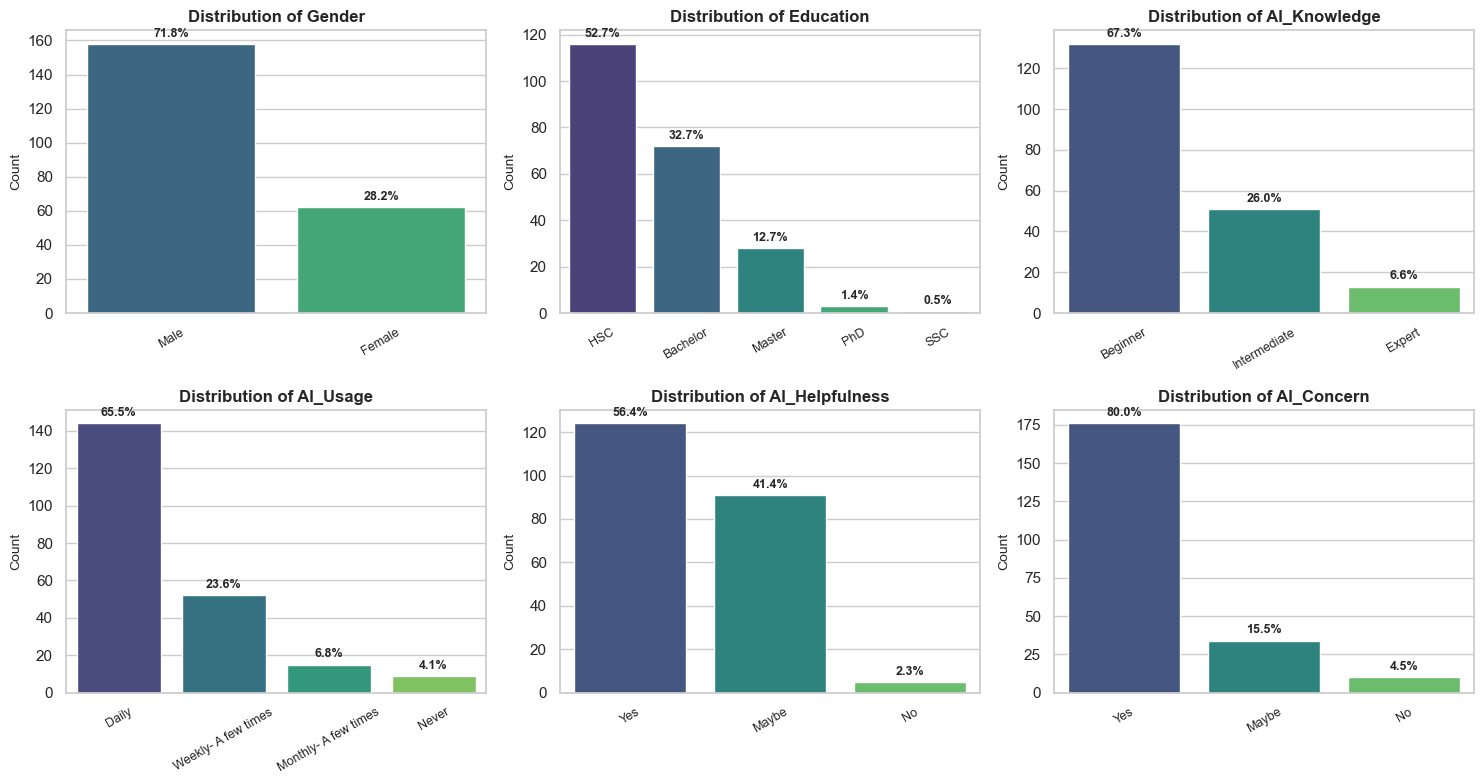

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of target columns
target_cols = ['Gender', 'Education', 'AI_Knowledge', 'AI_Usage', 'AI_Helpfulness', 'AI_Concern']

# Set the visual style
sns.set_theme(style="whitegrid")

# Swapped to 2 rows and 3 columns. Figsize adjusted for a horizontal layout.
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    # Calculate raw counts and percentages
    counts = data[col].value_counts()
    percentages = data[col].value_counts(normalize=True) * 100
    
    # Create the bar plot
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], hue=counts.index, legend=False, palette="viridis")
    
    # Add percentage labels on top of each bar
    for p, percent in zip(axes[i].patches, percentages):
        axes[i].annotate(f'{percent:.1f}%', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', 
                         fontsize=9, fontweight='bold', xytext=(0, 3),
                         textcoords='offset points')
    
    # Formatting
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=9)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [10]:
data["BirthYear"].value_counts()

BirthYear
2004    52
2005    43
2003    28
2006    13
2002    11
1997    11
2000    10
2001    10
1998     9
1996     7
1995     7
1999     6
1994     3
2007     3
1992     2
1993     2
1986     1
1973     1
1988     1
Name: count, dtype: int64

In [11]:
data['Age'] = 2025 - data['BirthYear']  # or current year
data = data.drop(columns=['BirthYear'])

In [12]:
data_encoded = pd.get_dummies(data, columns=['Gender','Education','Industry','AI_Knowledge','AI_Usage','AI_Helpfulness', 'AI_Concern'])
data_encoded = data_encoded

In [13]:
# Find all columns that are currently of the boolean type (True/False)
boolean_cols = data_encoded.select_dtypes(include='bool').columns

# Convert *only* those selected boolean columns to integer (1/0)
data_encoded[boolean_cols] = data_encoded[boolean_cols].astype(int)

In [14]:
categorical_column = ["AI_Services", "AI_Purpose", "AI_Influence"]

In [15]:
for name in categorical_column:
    data_encoded[name] = data_encoded[name].str.split(";")
    data_encoded_exploded = data_encoded.explode(name)
    data_encoded_services = pd.get_dummies(data_encoded_exploded[name]).groupby(data_encoded_exploded.index).sum()
    data_encoded = data_encoded.drop(name, axis=1).join(data_encoded_services)

In [16]:
data = data_encoded

In [17]:
data.tail()

,Age,Gender_Female,Gender_Male,Education_Bachelor,Education_HSC,Education_Master,Education_PhD,Education_SSC,Industry_Education,Industry_Finance,...,Education,Medical,Personal-Use,Project works,"Translation, Presentation, Severel Writings",Career decisions,Education/learning habits,None of the above,Online shopping,Social media content consumption
215,19,0,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,1,0,0,1
216,20,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
217,22,0,1,0,1,0,0,0,0,0,...,1,0,1,0,0,1,1,0,0,0
218,20,0,1,1,0,0,0,0,0,0,...,1,0,1,0,0,1,1,0,1,1
219,26,0,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,0,0,1,1


In [18]:
data.isna().sum()

Age                                            0
Gender_Female                                  0
Gender_Male                                    0
Education_Bachelor                             0
Education_HSC                                  0
Education_Master                               0
Education_PhD                                  0
Education_SSC                                  0
Industry_Education                             0
Industry_Finance                               0
Industry_Healthcare                            0
Industry_Marketing-Media                       0
Industry_Others                                0
Industry_Student                               0
Industry_Technology-IT                         0
AI_Knowledge_Beginner                          0
AI_Knowledge_Expert                            0
AI_Knowledge_Intermediate                      0
AI_Usage_Daily                                 0
AI_Usage_Monthly- A few times                  0
AI_Usage_Never      

In [19]:
data.to_csv('prepared_data.csv')